In [1]:
import glob
import json
import re
from pathlib import Path

import pandas as pd

from redel.utils import read_jsonl

SETTINGS = (
    "full",
    "root-fc",
    "baseline",
    "small-leaf",
    "small-all",
    "small-baseline",
    "short-context",
    "short-baseline",
)


def score_one(fp):
    fp = Path(fp)
    with open(fp) as f:
        scores = json.load(f)
    n_results = sum(1 for _ in read_jsonl(fp.parent / "results.jsonl"))
    acc = scores["acc"]["loose"]
    perf = scores["acc"]["strict"]
    r1p = scores["rouge"]["rouge1"]["precision"]
    r1r = scores["rouge"]["rouge1"]["recall"]
    r1f = scores["rouge"]["rouge1"]["fscore"]
    r2p = scores["rouge"]["rouge2"]["precision"]
    r2r = scores["rouge"]["rouge2"]["recall"]
    r2f = scores["rouge"]["rouge2"]["fscore"]
    rLp = scores["rouge"]["rougeL"]["precision"]
    rLr = scores["rouge"]["rougeL"]["recall"]
    rLf = scores["rouge"]["rougeL"]["fscore"]
    bleurt = scores["bleurt"]
    gptscore = scores["gpt"]
    return [n_results, acc, perf, r1p, r1r, r1f, r2p, r2r, r2f, rLp, rLr, rLf, bleurt, gptscore]

In [2]:
df = pd.DataFrame(
    columns=[
        "family",
        "setting",
        "n",
        "acc",
        "perf",
        "r1p",
        "r1r",
        "r1f",
        "r2p",
        "r2r",
        "r2f",
        "rLp",
        "rLr",
        "rLf",
        "bleurt",
        "gptscore",
    ]
)
for fp in glob.glob("../experiments/fanoutqa/*/*/score.json", recursive=True):
    setting_match = re.search(r"experiments/fanoutqa/(.+)/(.+)/score\.json", fp)
    model_family = setting_match[1]
    setting = setting_match[2]
    df.loc[len(df)] = [model_family, setting, *score_one(fp)]

# fig 1: no short

In [23]:
# filter and add dummy value for cohere hybrid
IGNORED = ("claude", "mistral")
filtered = df[(~df["family"].isin(IGNORED)) & (~df["setting"].str.contains("short"))]
filtered.loc[-1] = ["cohere-hf", "small-leaf", 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# sort
family_order = ["cohere-hf", "qwen3", "gpt-oss", "openai", "glm"]
system_order = ["small-baseline", "small-all", "small-leaf", "baseline", "root-fc", "full"]
filtered = filtered.sort_values(by=["family", "setting"], key=lambda col: col.map((family_order + system_order).index))
# filtered

# rename
filtered['setting'] = filtered['setting'].replace({"small-baseline": "Small (Baseline)", "small-all": "Small (ReDel)", "small-leaf": "Hybrid (ReDel)", "baseline": "Big (Baseline)", "root-fc": "Big (ReDel)", "full": "Big (Forced)"})
filtered['family'] = filtered['family'].replace({"cohere-hf": "Command-R", "qwen3": "Qwen 3", "gpt-oss": "GPT-OSS", "openai": "OpenAI", "glm": "GLM"})

/var/folders/0m/x9z2k6zn6cbgmyyfd94nmk300000gn/T/ipykernel_88382/1393342411.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered.loc[-1] = ["cohere-hf", "small-leaf", 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [24]:
# filtered.to_csv("foqa_scores.csv")
# filtered

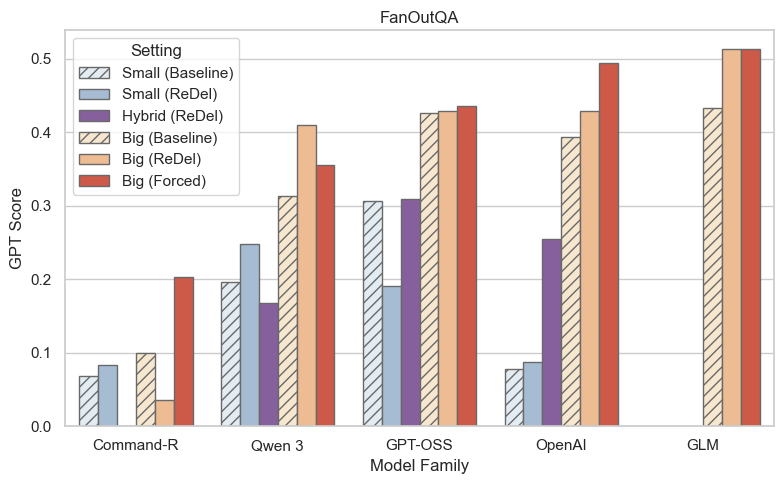

In [36]:
from matplotlib import pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the figure size (width, height)
plt.figure(figsize=(8, 5))

# Create the grouped bar chart
# https://colorbrewer2.org/#type=sequential&scheme=BuPu&n=6
colors = ["#e0ecf4", "#9ebcda", "#8856a7", "#fee8c8", "#fdbb84", "#e34a33"]
chart = sns.barplot(
    data=filtered,
    x='family',
    y='gptscore',
    hue='setting',
    palette=sns.color_palette(colors),
)

# --- Hatching Logic ---
# Get the handles and labels to identify which container corresponds to 'baseline'
# 1. Get the current handles and labels for the legend
#    (These represent the 'hue' categories: small-all, full, etc.)
handles, labels = chart.get_legend_handles_labels()

# 2. Iterate through the labels to find which indices correspond to any "baseline" setting
baseline_indices = [i for i, label in enumerate(labels) if "baseline" in label.lower()]

# Iterate over the containers (each container represents one hue/setting group)
for i, container in enumerate(chart.containers):
    # Ensure we don't exceed the labels list
    for bar in container:
        if i in baseline_indices:
            # Apply the hatch pattern
            bar.set_hatch('///')
        bar.set_edgecolor('dimgray')
        bar.set_linewidth(1)
for i, handle in enumerate(handles):
    if i in baseline_indices:
        # Apply the hatch pattern
        handle.set_hatch('///')
    handle.set_edgecolor('dimgray')
    handle.set_linewidth(1)


# Add labels and title
plt.xlabel('Model Family')
plt.ylabel('GPT Score')

# Rotate x-axis labels for better readability
# plt.xticks(rotation=45)

# Place the legend outside the plot area to prevent covering data
plt.title("FanOutQA")
plt.legend(title='Setting', loc='upper left')

plt.tight_layout()
plt.savefig('img/foqa_grouped.pdf')
plt.show()